<a href="https://colab.research.google.com/github/riya-nitnaware/riya-nitnaware.ML-LAB/blob/main/Extra_prac_10_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Riya Nitnaware_CS23015**

**Extra Prac_10: AIM: To perform Hierarchical Clustering using agglomerative methods and interpret dendrograms for cluster formation.**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path="/content/drive/MyDrive/ML_Dataset/Spotify_Songs_Dataset.csv"
df = pd.read_csv(path)
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [ ]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [ ]:
df.shape
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


In [ ]:
df = df.dropna()

In [ ]:
df = df.drop(['track_id','track_name','artist_name'], axis=1, errors='ignore')

In [ ]:
df = df.select_dtypes(include=['int64','float64'])

In [ ]:
df = df.sample(n=500, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

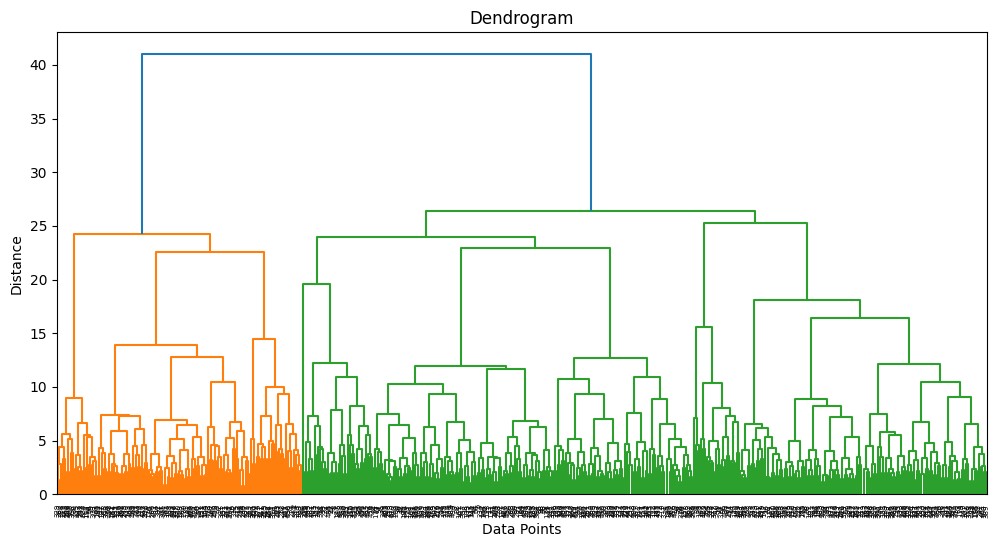

In [ ]:
import scipy.cluster.hierarchy as sch
plt.figure(figsize=(12,6))
sch.dendrogram(sch.linkage(scaled_data, method='ward'))
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
y_pred = hc.fit_predict(scaled_data)
print(y_pred)

[1 2 1 0 2 2 0 2 2 2 1 2 1 0 1 0 0 2 2 0 0 0 2 0 2 0 0 2 1 2 1 0 2 1 2 2 2
 2 0 1 1 2 2 1 0 0 0 2 2 2 2 2 0 2 2 2 2 2 0 2 2 1 0 1 1 2 2 0 2 1 0 1 2 2
 0 1 2 2 2 1 2 1 0 0 0 2 2 1 2 2 1 1 1 0 2 1 0 0 2 2 0 0 2 0 1 1 2 0 1 2 2
 1 2 1 0 2 2 2 1 0 1 0 2 2 1 2 0 0 0 2 2 2 2 2 0 2 2 2 0 0 0 1 1 2 2 2 2 0
 0 0 0 0 1 2 1 2 0 2 1 2 1 2 1 0 2 2 2 0 2 0 1 2 2 2 1 2 0 2 2 2 0 1 0 1 0
 0 0 1 1 0 2 1 0 1 0 0 2 0 1 2 2 0 2 1 2 0 0 0 1 2 0 0 0 1 1 0 2 0 1 1 2 0
 2 2 0 1 1 2 2 0 2 0 1 1 2 2 1 2 0 2 2 0 0 0 2 1 2 2 0 2 1 2 1 1 1 1 2 2 2
 0 0 2 1 0 2 0 1 2 2 1 1 1 2 2 1 0 2 0 0 2 1 1 2 0 1 0 0 2 0 0 2 1 2 1 0 2
 0 0 2 0 0 1 1 1 2 1 0 2 0 1 1 0 1 0 0 2 2 0 0 2 2 2 0 1 0 2 1 0 0 1 2 2 2
 0 1 2 2 1 2 0 0 2 1 2 2 0 2 1 0 2 2 1 0 2 1 0 2 2 1 1 1 1 2 2 0 2 1 1 2 0
 2 1 2 0 2 1 1 0 0 0 0 1 1 2 2 2 0 2 2 0 1 2 1 1 1 2 0 0 2 2 0 2 2 0 2 2 2
 2 0 1 2 2 1 2 0 1 0 0 2 0 1 2 0 2 1 2 0 2 2 2 1 2 1 0 2 2 2 2 2 0 1 2 1 0
 0 2 0 0 2 1 1 2 2 0 1 1 2 0 2 2 0 0 2 0 0 1 0 1 1 1 2 2 0 0 0 0 1 2 1 0 2
 1 2 0 0 2 2 1 0 2 2 0 0 

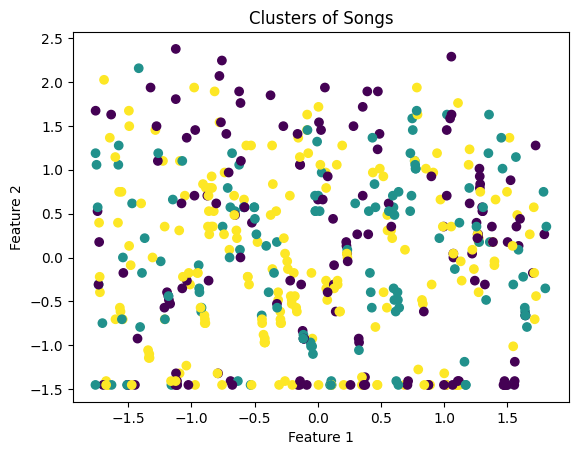

In [ ]:
plt.scatter(scaled_data[:,0], scaled_data[:,1], c=y_pred)
plt.title("Clusters of Songs")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()